# Step 6: Visualisasi & Report
## Presentasi Hasil Analisis

**Tujuan**:
- Membuat visualisasi komprehensif untuk laporan eksekutif
- Menampilkan insight dari Scoring Engine & Decision Engine
- Menyajikan perbandingan model performa
- Output: Semua chart tersimpan di folder `outputs/charts/`

---

## Visualisasi yang akan dibuat:

1. **Radar Chart** - Profil 4 aspek sentimen per produk
2. **Heatmap** - Aspect score vs kategori produk
3. **WordCloud** - Kata paling sering dari review negatif
4. **Decision Distribution** - Pie chart keputusan akhir
5. **Confusion Matrix** - Model performa (opsional, jika ada ground truth)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set up paths
BASE_PATH = Path('../')
ABSA_RESULTS = BASE_PATH / 'absa_results.csv'
PRODUCT_DECISIONS = BASE_PATH / 'product_decisions.csv'
OUTPUT_DIR = BASE_PATH / 'outputs' / 'charts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loading data...")
df_absa = pd.read_csv(ABSA_RESULTS)
df_decisions = pd.read_csv(PRODUCT_DECISIONS)

print(f"ABSA Results: {df_absa.shape}")
print(f"Product Decisions: {df_decisions.shape}")
print(f"Output directory: {OUTPUT_DIR}")

Loading data...
ABSA Results: (30000, 13)
Product Decisions: (14948, 13)
Output directory: ..\outputs\charts


## 1. Decision Distribution - Pie Chart

 Saved: 01_decision_distribution.png


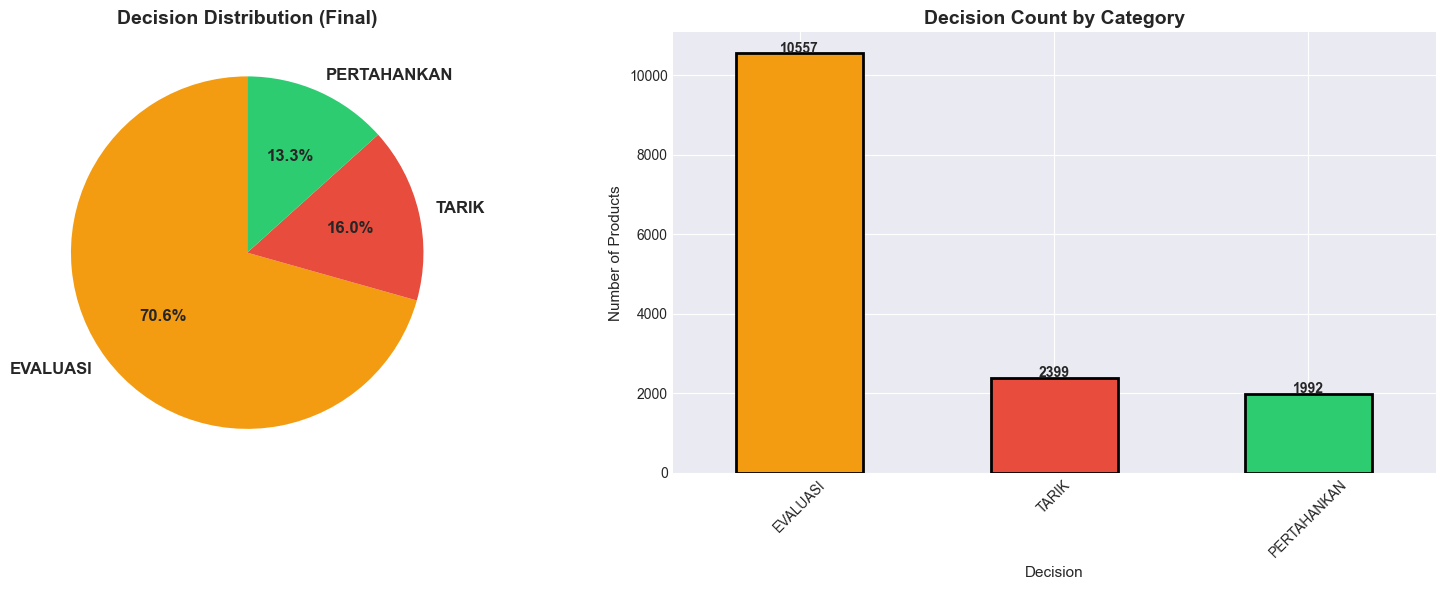

In [2]:
# Create pie chart for decision distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
decision_counts = df_decisions['decision'].value_counts()
colors = {'PERTAHANKAN': '#2ecc71', 'EVALUASI': '#f39c12', 'TARIK': '#e74c3c'}
colors_list = [colors[d] for d in decision_counts.index]

wedges, texts, autotexts = ax1.pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct='%1.1f%%',
    colors=colors_list,
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
ax1.set_title('Decision Distribution (Final)', fontsize=14, fontweight='bold')

# Bar chart
decision_counts.plot(kind='bar', ax=ax2, color=colors_list, edgecolor='black', linewidth=2)
ax2.set_title('Decision Count by Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decision', fontsize=11)
ax2.set_ylabel('Number of Products', fontsize=11)
ax2.set_xticklabels(decision_counts.index, rotation=45)

# Add count labels on bars
for i, v in enumerate(decision_counts.values):
    ax2.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_decision_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 01_decision_distribution.png")
plt.show()

## 2. Product Score Distribution

 Saved: 02_product_score_distribution.png


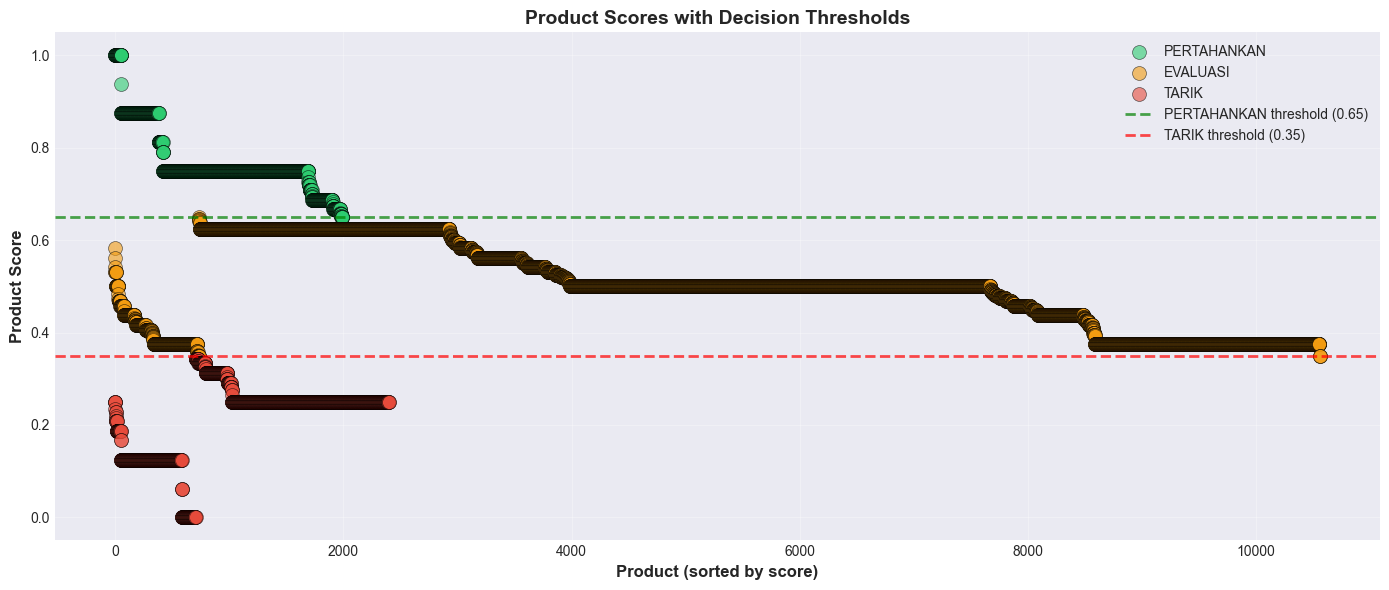

In [3]:
# Product score distribution with decision colors
fig, ax = plt.subplots(figsize=(14, 6))

# Create color mapping for decision
decision_color_map = {'PERTAHANKAN': '#2ecc71', 'EVALUASI': '#f39c12', 'TARIK': '#e74c3c'}
colors_plot = [decision_color_map[d] for d in df_decisions['decision']]

# Scatter plot
for decision, color in decision_color_map.items():
    mask = df_decisions['decision'] == decision
    ax.scatter(
        range(mask.sum()),
        df_decisions[mask]['product_score'].values,
        c=color,
        label=decision,
        alpha=0.6,
        s=100,
        edgecolor='black',
        linewidth=0.5
    )

# Add threshold lines
ax.axhline(y=0.65, color='green', linestyle='--', linewidth=2, label='PERTAHANKAN threshold (0.65)', alpha=0.7)
ax.axhline(y=0.35, color='red', linestyle='--', linewidth=2, label='TARIK threshold (0.35)', alpha=0.7)

ax.set_ylabel('Product Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Product (sorted by score)', fontsize=12, fontweight='bold')
ax.set_title('Product Scores with Decision Thresholds', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_product_score_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 02_product_score_distribution.png")
plt.show()

## 3. Aspect Scores Heatmap

 Saved: 03_aspect_scores_heatmap.png


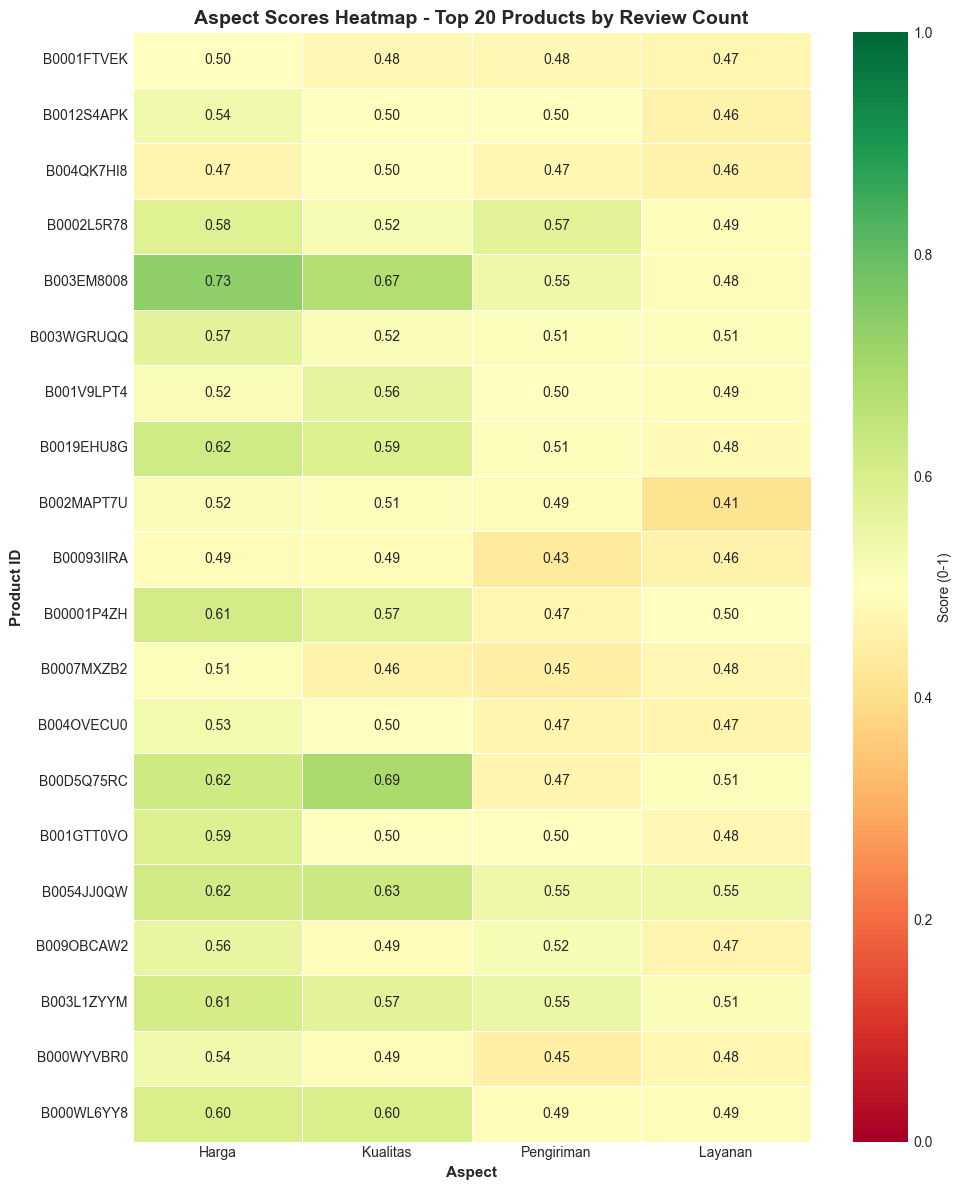

In [4]:
# Get top 20 products by review count
top_products = df_decisions.nlargest(20, 'review_count')

# Extract aspect scores
aspect_data = top_products[[
    'product_id',
    'aspect_harga_score',
    'aspect_kualitas_score',
    'aspect_pengiriman_score',
    'aspect_layanan_score'
]].set_index('product_id')

aspect_data.columns = ['Harga', 'Kualitas', 'Pengiriman', 'Layanan']

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    aspect_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Score (0-1)'},
    linewidths=0.5,
    ax=ax
)

ax.set_title('Aspect Scores Heatmap - Top 20 Products by Review Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Aspect', fontsize=11, fontweight='bold')
ax.set_ylabel('Product ID', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_aspect_scores_heatmap.png', dpi=300, bbox_inches='tight')
print(" Saved: 03_aspect_scores_heatmap.png")
plt.show()

## 4. Radar Chart - Sample Products

 Saved: 04_radar_chart_sample.png


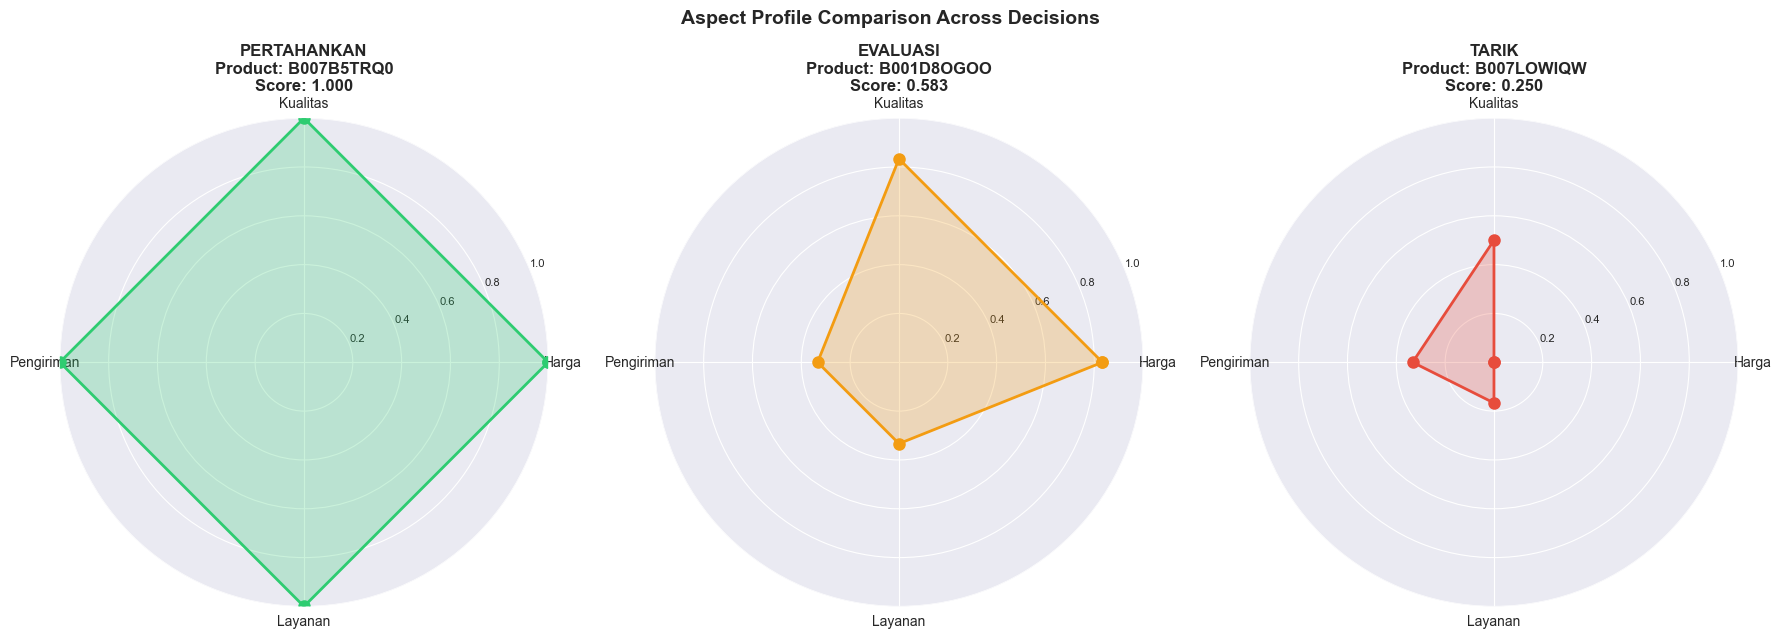

In [5]:
# Select sample products from each decision category
sample_keep = df_decisions[df_decisions['decision'] == 'PERTAHANKAN'].iloc[0]
sample_eval = df_decisions[df_decisions['decision'] == 'EVALUASI'].iloc[0]
sample_tarik = df_decisions[df_decisions['decision'] == 'TARIK'].iloc[0]

samples = [
    (sample_keep, 'PERTAHANKAN', '#2ecc71'),
    (sample_eval, 'EVALUASI', '#f39c12'),
    (sample_tarik, 'TARIK', '#e74c3c')
]

# Create radar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))

categories = ['Harga', 'Kualitas', 'Pengiriman', 'Layanan']
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for ax, (sample, decision, color) in zip(axes, samples):
    values = [
        sample['aspect_harga_score'],
        sample['aspect_kualitas_score'],
        sample['aspect_pengiriman_score'],
        sample['aspect_layanan_score']
    ]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, color=color, markersize=8)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
    ax.grid(True)
    
    title = f"{decision}\nProduct: {sample['product_id']}\nScore: {sample['product_score']:.3f}"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Aspect Profile Comparison Across Decisions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_radar_chart_sample.png', dpi=300, bbox_inches='tight')
print(" Saved: 04_radar_chart_sample.png")
plt.show()

## 5. Aspect Score Comparison

 Saved: 05_aspect_comparison_boxplot.png


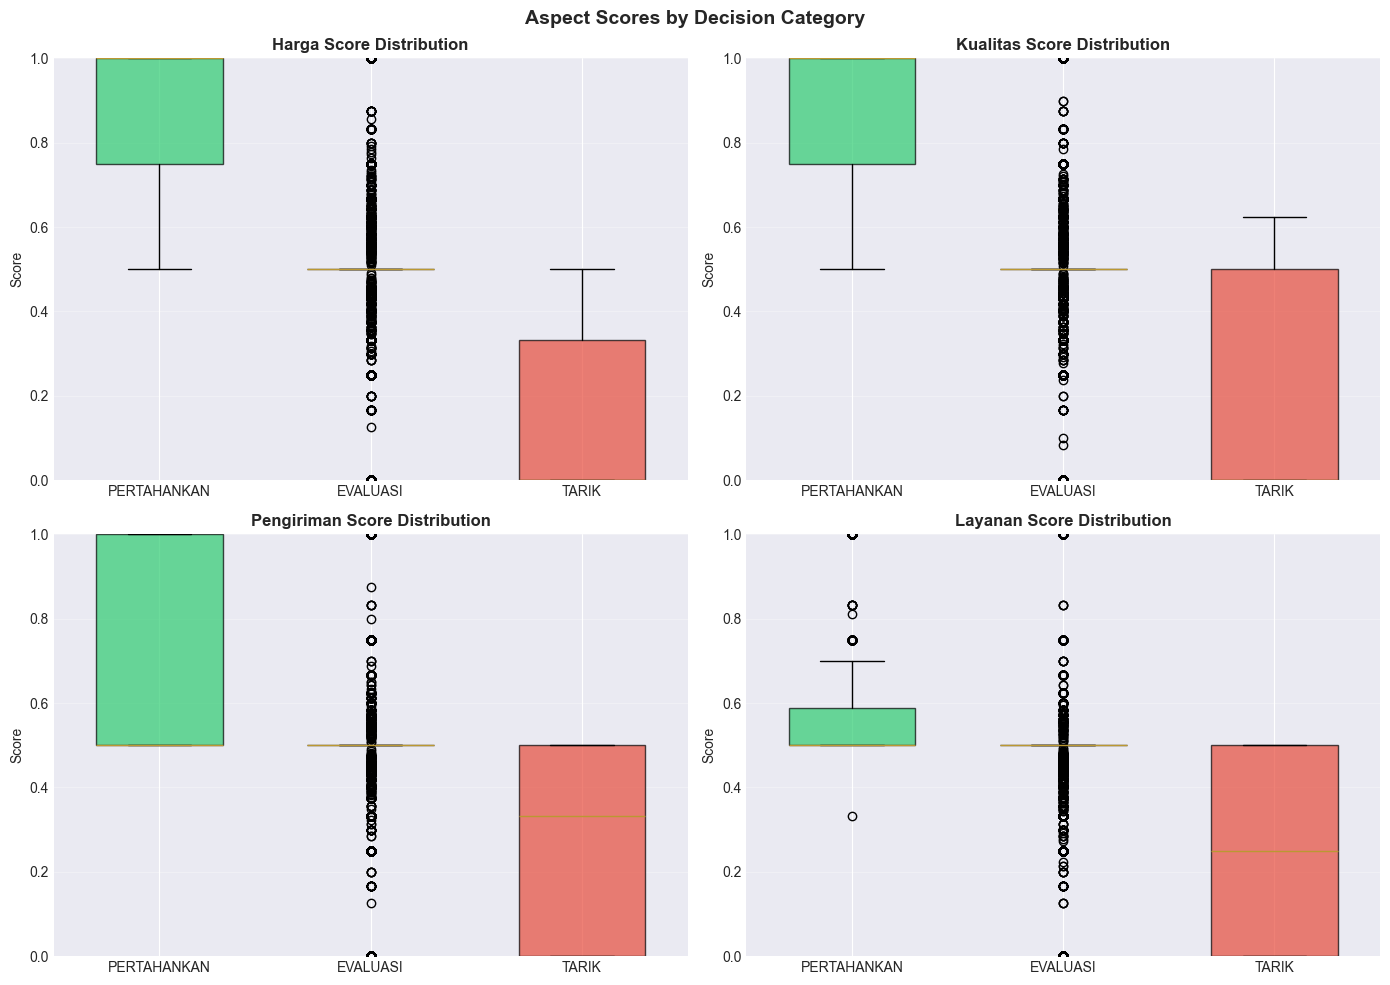

In [6]:
# Compare aspect scores by decision
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

aspects = [
    ('aspect_harga_score', 'Harga'),
    ('aspect_kualitas_score', 'Kualitas'),
    ('aspect_pengiriman_score', 'Pengiriman'),
    ('aspect_layanan_score', 'Layanan')
]

colors_dict = {'PERTAHANKAN': '#2ecc71', 'EVALUASI': '#f39c12', 'TARIK': '#e74c3c'}

for idx, (ax, (col, label)) in enumerate(zip(axes.flat, aspects)):
    data_to_plot = [df_decisions[df_decisions['decision'] == d][col].values for d in ['PERTAHANKAN', 'EVALUASI', 'TARIK']]
    
    bp = ax.boxplot(
        data_to_plot,
        labels=['PERTAHANKAN', 'EVALUASI', 'TARIK'],
        patch_artist=True,
        widths=0.6
    )
    
    for patch, decision in zip(bp['boxes'], ['PERTAHANKAN', 'EVALUASI', 'TARIK']):
        patch.set_facecolor(colors_dict[decision])
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(f'{label} Score Distribution', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Aspect Scores by Decision Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_aspect_comparison_boxplot.png', dpi=300, bbox_inches='tight')
print(" Saved: 05_aspect_comparison_boxplot.png")
plt.show()

## 6. WordCloud from Negative Reviews

 Saved: 06_wordcloud_negative_reviews.png


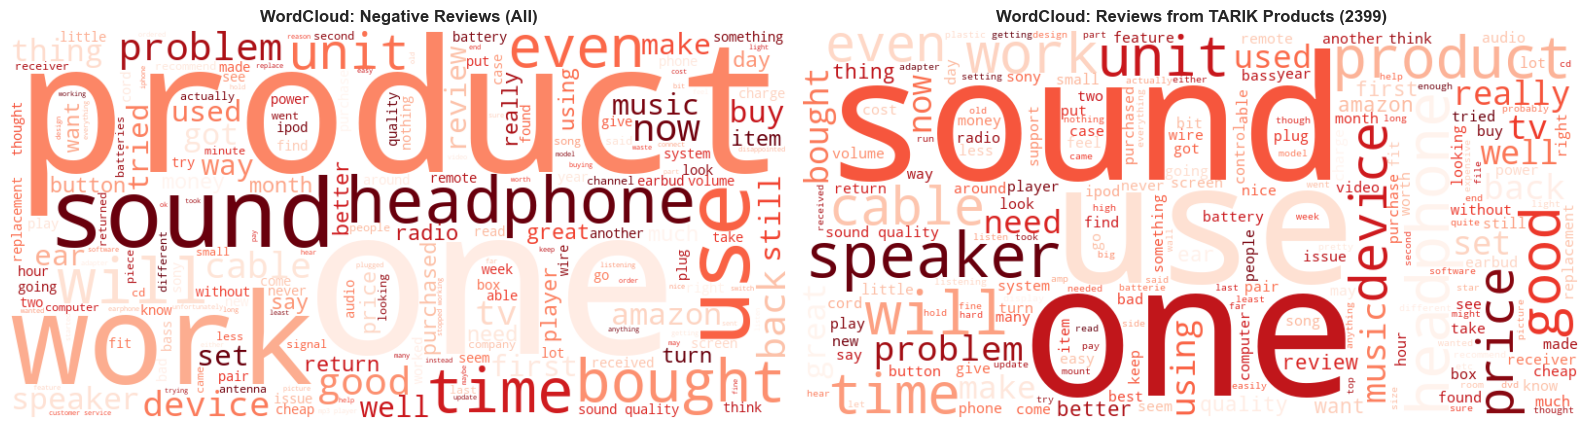

In [7]:
# Get negative reviews (star_rating <= 2)
df_negative = df_absa[df_absa['star_rating'] <= 2]

# Combine all negative review text
negative_text = ' '.join(df_negative['review_body'].dropna().astype(str))

# Create WordCloud
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WordCloud 1: All negative reviews
wordcloud1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
axes[0].imshow(wordcloud1, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('WordCloud: Negative Reviews (All)', fontsize=12, fontweight='bold')

# WordCloud 2: Most common words in TARIK products
tarik_products = df_decisions[df_decisions['decision'] == 'TARIK']['product_id'].values
df_tarik_reviews = df_absa[df_absa['product_id'].isin(tarik_products)]
tarik_text = ' '.join(df_tarik_reviews['review_body'].dropna().astype(str))

wordcloud2 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(tarik_text)
axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(f'WordCloud: Reviews from TARIK Products ({len(tarik_products)})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_wordcloud_negative_reviews.png', dpi=300, bbox_inches='tight')
print(" Saved: 06_wordcloud_negative_reviews.png")
plt.show()

## 7. Priority Distribution

 Saved: 07_priority_distribution.png


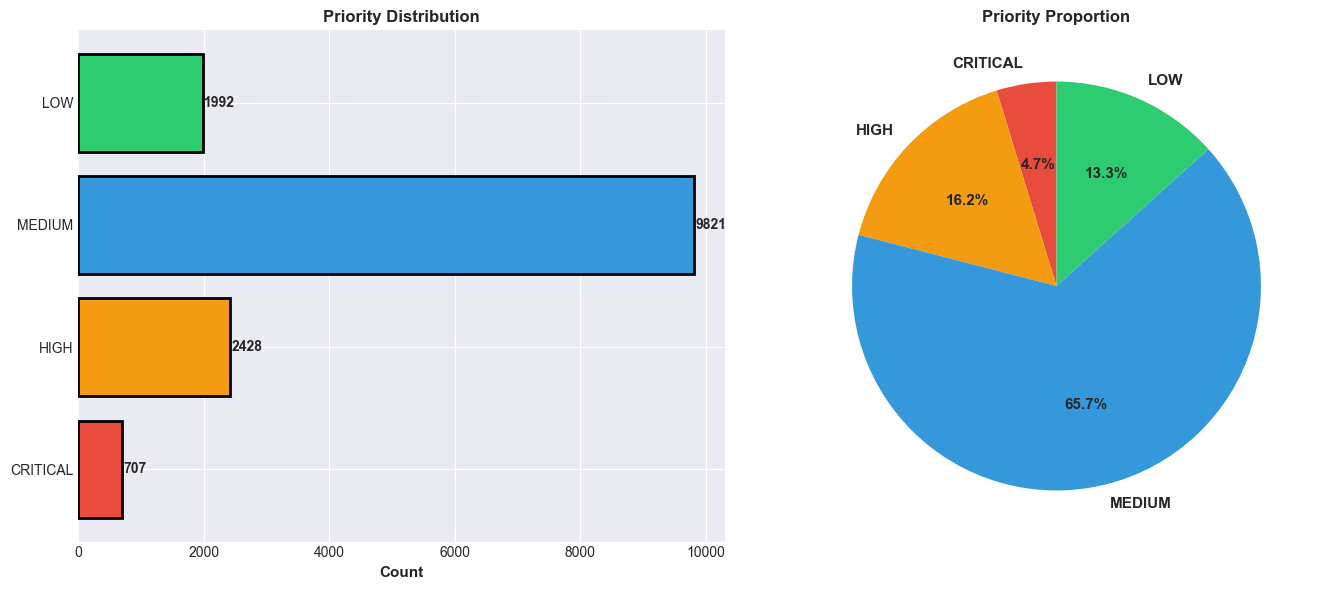

In [8]:
# Priority distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

priority_counts = df_decisions['priority'].value_counts()
priority_order = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
priority_colors = {'CRITICAL': '#e74c3c', 'HIGH': '#f39c12', 'MEDIUM': '#3498db', 'LOW': '#2ecc71'}

# Reorder and get colors
priority_ordered = [p for p in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'] if p in priority_counts.index]
priority_values = [priority_counts[p] for p in priority_ordered]
colors_priority = [priority_colors[p] for p in priority_ordered]

# Bar chart
axes[0].barh(priority_ordered, priority_values, color=colors_priority, edgecolor='black', linewidth=2)
axes[0].set_xlabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Priority Distribution', fontsize=12, fontweight='bold')

for i, v in enumerate(priority_values):
    axes[0].text(v + 20, i, str(v), va='center', fontweight='bold')

# Pie chart
axes[1].pie(
    priority_values,
    labels=priority_ordered,
    autopct='%1.1f%%',
    colors=colors_priority,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[1].set_title('Priority Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_priority_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 07_priority_distribution.png")
plt.show()

## 8. Summary Statistics & Report

 Saved: 08_executive_summary.png


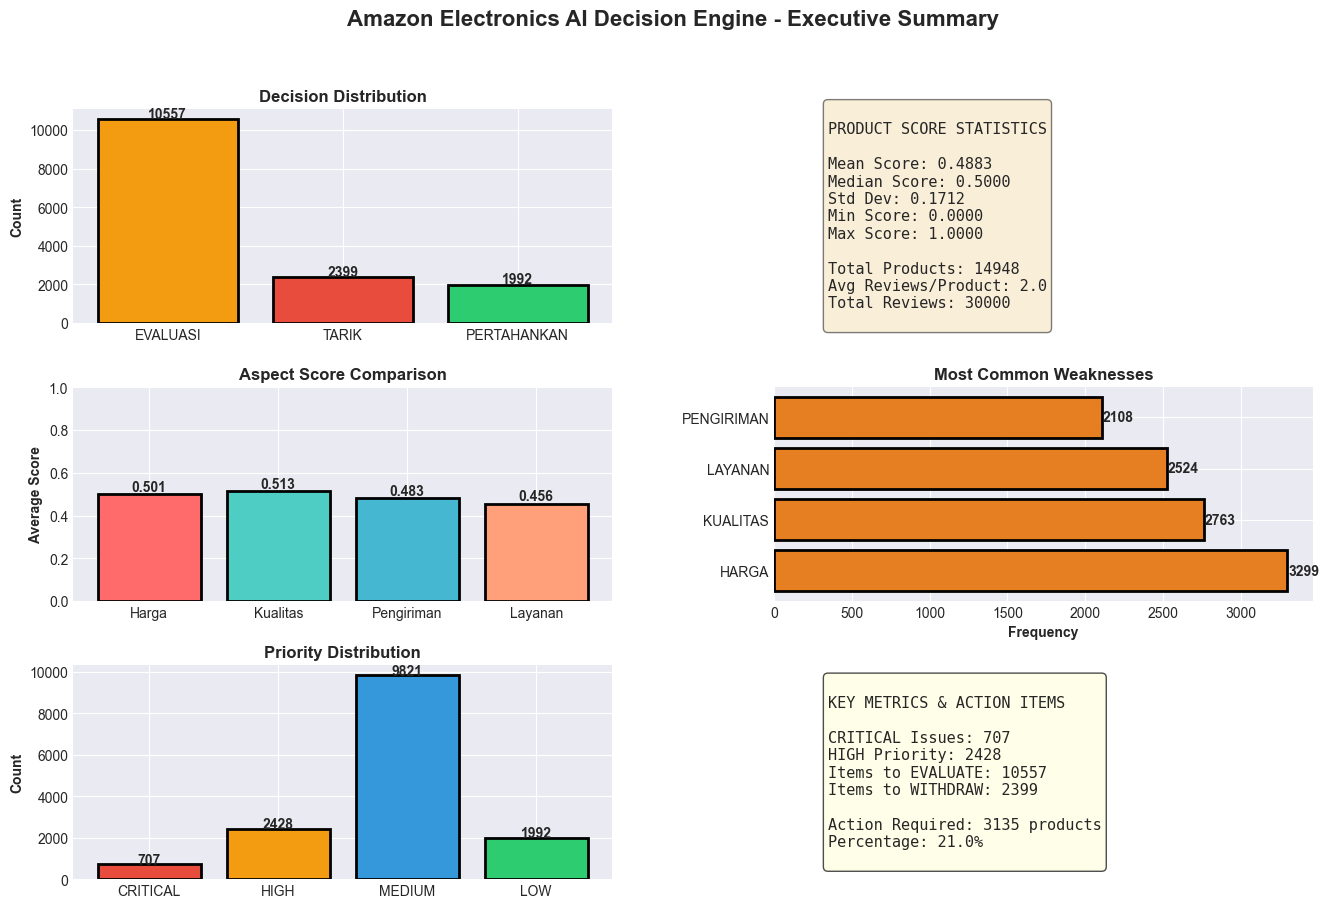

In [9]:
# Create summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Amazon Electronics AI Decision Engine - Executive Summary', fontsize=16, fontweight='bold', y=0.98)

# 1. Decision Summary (top-left)
ax1 = fig.add_subplot(gs[0, 0])
decision_counts = df_decisions['decision'].value_counts()
colors_list = [colors_dict[d] for d in decision_counts.index]
ax1.bar(range(len(decision_counts)), decision_counts.values, color=colors_list, edgecolor='black', linewidth=2)
ax1.set_xticks(range(len(decision_counts)))
ax1.set_xticklabels(decision_counts.index)
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Decision Distribution', fontweight='bold')
for i, v in enumerate(decision_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Score Statistics (top-right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
stats_text = f"""
PRODUCT SCORE STATISTICS

Mean Score: {df_decisions['product_score'].mean():.4f}
Median Score: {df_decisions['product_score'].median():.4f}
Std Dev: {df_decisions['product_score'].std():.4f}
Min Score: {df_decisions['product_score'].min():.4f}
Max Score: {df_decisions['product_score'].max():.4f}

Total Products: {len(df_decisions)}
Avg Reviews/Product: {df_decisions['review_count'].mean():.1f}
Total Reviews: {df_decisions['review_count'].sum()}
"""
ax2.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Aspect Scores (middle-left)
ax3 = fig.add_subplot(gs[1, 0])
aspect_cols = ['aspect_harga_score', 'aspect_kualitas_score', 'aspect_pengiriman_score', 'aspect_layanan_score']
aspect_names = ['Harga', 'Kualitas', 'Pengiriman', 'Layanan']
aspect_means = [df_decisions[col].mean() for col in aspect_cols]
bars = ax3.bar(aspect_names, aspect_means, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black', linewidth=2)
ax3.set_ylabel('Average Score', fontweight='bold')
ax3.set_title('Aspect Score Comparison', fontweight='bold')
ax3.set_ylim(0, 1)
for bar, score in zip(bars, aspect_means):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Weakness Analysis (middle-right)
ax4 = fig.add_subplot(gs[1, 1])
weakness_list = []
for weaknesses in df_decisions[df_decisions['weakness_flags'] != 'NONE']['weakness_flags']:
    weakness_list.extend(weaknesses.split(','))
weakness_counts = pd.Series(weakness_list).value_counts()
ax4.barh(weakness_counts.index, weakness_counts.values, color='#e67e22', edgecolor='black', linewidth=2)
ax4.set_xlabel('Frequency', fontweight='bold')
ax4.set_title('Most Common Weaknesses', fontweight='bold')
for i, v in enumerate(weakness_counts.values):
    ax4.text(v + 5, i, str(v), va='center', fontweight='bold')

# 5. Priority (bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
priority_order_list = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
priority_counts = df_decisions['priority'].value_counts()
priority_plot = [priority_counts.get(p, 0) for p in priority_order_list]
colors_priority_plot = [priority_colors[p] for p in priority_order_list]
ax5.bar(priority_order_list, priority_plot, color=colors_priority_plot, edgecolor='black', linewidth=2)
ax5.set_ylabel('Count', fontweight='bold')
ax5.set_title('Priority Distribution', fontweight='bold')
for i, v in enumerate(priority_plot):
    if v > 0:
        ax5.text(i, v + 10, str(v), ha='center', fontweight='bold')

# 6. Key Metrics (bottom-right)
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
critical_count = (df_decisions['priority'] == 'CRITICAL').sum()
high_count = (df_decisions['priority'] == 'HIGH').sum()
tarik_count = (df_decisions['decision'] == 'TARIK').sum()
eval_count = (df_decisions['decision'] == 'EVALUASI').sum()

metrics_text = f"""
KEY METRICS & ACTION ITEMS

CRITICAL Issues: {critical_count}
HIGH Priority: {high_count}
Items to EVALUATE: {eval_count}
Items to WITHDRAW: {tarik_count}

Action Required: {critical_count + high_count} products
Percentage: {(critical_count + high_count) / len(df_decisions) * 100:.1f}%
"""
ax6.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace', verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.savefig(OUTPUT_DIR / '08_executive_summary.png', dpi=300, bbox_inches='tight')
print(" Saved: 08_executive_summary.png")
plt.show()

## 9. Final Report & Summary

In [11]:
print("AMAZON ELECTRONICS AI DECISION ENGINE - FINAL REPORT")

print(f"\n DATASET OVERVIEW")
print(f"  Total Reviews Analyzed: {len(df_absa):,}")
print(f"  Total Products Scored: {len(df_decisions):,}")
print(f"  Avg Reviews per Product: {df_decisions['review_count'].mean():.1f}")

print(f"\n OVERALL SENTIMENT SCORE")
print(f"  Mean Product Score: {df_decisions['product_score'].mean():.4f}")
print(f"  Median: {df_decisions['product_score'].median():.4f}")
print(f"  Range: {df_decisions['product_score'].min():.4f} - {df_decisions['product_score'].max():.4f}")

print(f"\n DECISION BREAKDOWN")
for decision in ['PERTAHANKAN', 'EVALUASI', 'TARIK']:
    count = (df_decisions['decision'] == decision).sum()
    pct = count / len(df_decisions) * 100
    print(f"  {decision:15} : {count:6,} products ({pct:5.1f}%)")

print(f"\n PRIORITY SUMMARY")
for priority in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    count = (df_decisions['priority'] == priority).sum()
    pct = count / len(df_decisions) * 100
    print(f"  {priority:10} : {count:6,} products ({pct:5.1f}%)")

print(f"\n WEAKNESS ANALYSIS")
weakness_list = []
for weaknesses in df_decisions[df_decisions['weakness_flags'] != 'NONE']['weakness_flags']:
    weakness_list.extend(weaknesses.split(','))
weakness_counts = pd.Series(weakness_list).value_counts()
for aspect, count in weakness_counts.items():
    print(f"  {aspect:12} : {count:6,} products")

print(f"\n ASPECT SCORES (Average)")
aspects_avg = {
    'Harga': df_decisions['aspect_harga_score'].mean(),
    'Kualitas': df_decisions['aspect_kualitas_score'].mean(),
    'Pengiriman': df_decisions['aspect_pengiriman_score'].mean(),
    'Layanan': df_decisions['aspect_layanan_score'].mean()
}
for aspect, score in aspects_avg.items():
    print(f"  {aspect:12} : {score:.4f}")

print(f"\n OUTPUTS")
print(f"  All charts saved in: {OUTPUT_DIR}")
charts_created = list(OUTPUT_DIR.glob('*.png'))
for chart in sorted(charts_created):
    print(f" {chart.name}")

print(f"\n" + "="*80)
print("STEP 6 COMPLETE - Visualisasi & Report")
print("="*80)
print(f"\n PROJECT COMPLETE!")
print(f"\nNext Steps:")
print(f"  1. Review executive summary: 08_executive_summary.png")
print(f"  2. Share insights with stakeholders")
print(f"  3. Implement decisions for CRITICAL & HIGH priority products")
print(f"  4. Monitor EVALUASI products for improvement")

AMAZON ELECTRONICS AI DECISION ENGINE - FINAL REPORT

 DATASET OVERVIEW
  Total Reviews Analyzed: 30,000
  Total Products Scored: 14,948
  Avg Reviews per Product: 2.0

 OVERALL SENTIMENT SCORE
  Mean Product Score: 0.4883
  Median: 0.5000
  Range: 0.0000 - 1.0000

 DECISION BREAKDOWN
  PERTAHANKAN     :  1,992 products ( 13.3%)
  EVALUASI        : 10,557 products ( 70.6%)
  TARIK           :  2,399 products ( 16.0%)

 PRIORITY SUMMARY
  CRITICAL   :    707 products (  4.7%)
  HIGH       :  2,428 products ( 16.2%)
  MEDIUM     :  9,821 products ( 65.7%)
  LOW        :  1,992 products ( 13.3%)

 WEAKNESS ANALYSIS
  HARGA        :  3,299 products
  KUALITAS     :  2,763 products
  LAYANAN      :  2,524 products
  PENGIRIMAN   :  2,108 products

 ASPECT SCORES (Average)
  Harga        : 0.5011
  Kualitas     : 0.5130
  Pengiriman   : 0.4831
  Layanan      : 0.4558

 OUTPUTS
  All charts saved in: ..\outputs\charts
 01_decision_distribution.png
 02_product_score_distribution.png
 03_aspect